In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from funcs import metrics
from funcs import neural_model

In [2]:
def setMyPlot(figsize):
    plt.figure(figsize=figsize)
    plt.rcParams['xtick.direction'] = 'in'
    plt.rcParams['ytick.direction'] = 'in'
    ax = plt.gca()
    width=2
    ax.spines['top'].set_visible(False)
#     ax.spines['top'].set_linewidth(width)
    ax.spines['bottom'].set_linewidth(width)
    ax.spines['left'].set_linewidth(width)
#     ax.spines['right'].set_linewidth(width)
    ax.spines['right'].set_visible(False)
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13) 

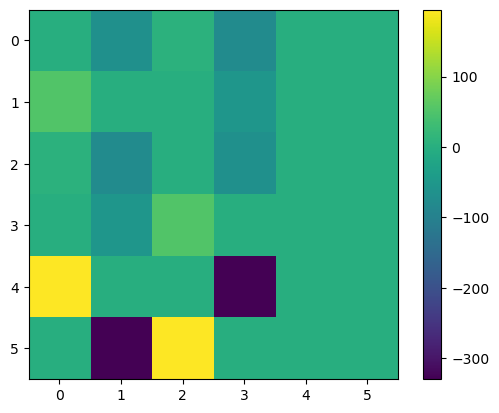

In [3]:
EF = neural_model.WC_Neuron(Ja = 140.0, Jdp = 110.0, s0=0.011,   
                   taus = 3.9615, taua = 166.80, taudp = 1.8765, taur = 250.2, 
                   x0 = 0.9223, u0 = 0.1, uFlag = 1,UU = 0.03)
IF = neural_model.WC_Neuron(Ja = 180.0, Jdp = 0.0, s0=0.012,
               taus = 5.4210, taua = 62.55, taudp = 1000.0, taur = 225.0, 
               x0 = 0.4796, u0 = 0.4, uFlag = 0)
EX = neural_model.WC_Neuron(Ja = 140.0, Jdp = 110.0, s0=0.01,
               taus = 3.9615, taua = 166.80, taudp = 1.8765, taur = 250.2, 
               x0 = 0.9223, u0 = 0.1, uFlag = 1,UU = 0.03)
IX = neural_model.WC_Neuron(Ja = 180.0, Jdp = 0.0, s0=0.01,
               taus = 5.4210, taua = 62.55, taudp = 1000.0, taur = 225.0, 
               x0 = 0.4796, u0 = 0.4, uFlag = 0)
MF = neural_model.WC_Neuron(Ja = 140.0, Jdp = 0.0,
               taus = 5.4210, taua = 500.4, taudp = 1000.0, taur = 225.0, 
               x0 = 0.4796, u0 = 0.4, uFlag = 0)
MX = neural_model.WC_Neuron(Ja = 140.0, Jdp = 0.0, 
               taus = 5.4210, taua = 500.4, taudp = 1000.0, taur = 225.0, 
               x0 = 0.4796, u0 = 0.4, uFlag = 0)

Jee2 = 0
Jie2 = 52 
Jei2 = 66 
Jii2 = 0 
Jee = 6.5 
Jii = 55 
Jei = 77 

Jme=195 
Jmi=330 

V3prop = 0.2

Escale = 1*(1-V3prop)+V3prop
V1scale =1
V2bscale = 1
Iscale = 1
V2b_inp_scale = 1
V1_inp_scale = 1

V1F = 0.4545 # 
V1X = 0.8181 # 
V2bF = 0.5455 # 
V2bX = 0.1819 # 

V1_inp_scale =  0.0
V2b_inp_scale = 0.0

I0I = 0.3
I0E = 0.6

IscaleX = (V1scale* V1X+ V2bscale*V2bX)
IscaleF = (V1scale* V1F+ V2bscale*V2bF)


I0I_F = I0I + V1_inp_scale*V1F+V2b_inp_scale*V2bF
I0I_X = I0I + V1_inp_scale*V1X+V2b_inp_scale*V2bX


ListWCNeuron = [EF, IF, EX, IX, MF, MX]

ConnMat = np.array([[Escale*Jee2, IscaleF*-Jei2, Escale*Jee, IscaleX*-Jei, 0.0, 0.0],
                   [Escale*Jie2, IscaleF*-Jii2, 0.0, IscaleX*-Jii, 0.0, 0.0],
                   [Escale*Jee, IscaleF*-Jei, Escale*Jee2, IscaleX*-Jei2, 0.0, 0.0],
                   [0.0, IscaleF*-Jii, Escale*Jie2, IscaleX*-Jii2, 0.0, 0.0],
                   [Escale * Jme, 0.0, 0.0, -IscaleX*Jmi, 0.0, 0.0],
                   [0.0, -IscaleF*Jmi,Escale * Jme, 0.0, 0.0, 0.0]])

plt.imshow(ConnMat)
plt.colorbar()
# print(ConnMat)

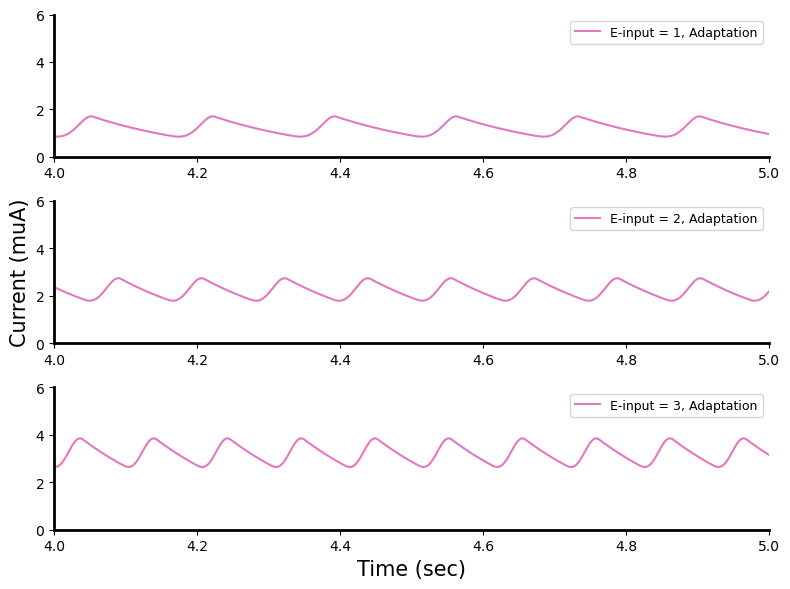

In [4]:
# current with/without facilitation

#  facilitation
facilitation = 1 # 1: with facilitation, 0: without facilitation
clist = ['tab:cyan','tab:pink']
EF = neural_model.WC_Neuron(Ja = 140.0, Jdp = 110.0, s0=0.011,   
                   taus = 3.9615, taua = 166.80, taudp = 1.8765, taur = 250.2, 
                   x0 = 0.9223, u0 = 0.1, uFlag = facilitation,UU = 0.03)
EX = neural_model.WC_Neuron(Ja = 140.0, Jdp = 110.0, s0=0.011,   
                   taus = 3.9615, taua = 166.80, taudp = 1.8765, taur = 250.2, 
                   x0 = 0.9223, u0 = 0.1, uFlag = facilitation,UU = 0.03)
ListWCNeuron = [EF, IF, EX, IX, MF, MX]

ind = 0

fig, axs = plt.subplots(3, figsize = (8,6))
width=2
for I0E in [1.0,2.0,3.0]:
    FinalNN = neural_model.WC_NN(ListWCNeuron,ConnMat, beta = 0.011, dt = 0.1)
    T = 6000
    FinalNN.init_dynamics(T)
    inp_arr = [I0E, I0I_F, I0E, I0I_X, 0.0, 0.0]
    for i in range(FinalNN.Npts):
        FinalNN.update(inp_arr)
        FinalNN.record(i)
    tt = np.linspace(0, T, FinalNN.Npts)

    axs[ind].plot(tt/1000, FinalNN.aarr[0], 
                  label = 'E-input = '+str(int(I0E))+', Adaptation',c=clist[facilitation])
#     axs[ind].plot(tt/1000, FinalNN.dparr[0], 
#                   label = 'E-input = '+str(int(I0E))+', Depolarization')
    axs[ind].set_xlim([4,5])
    axs[ind].set_ylim([0.0, 6.0])
    axs[ind].legend(fontsize = 9,ncols=2)
    axs[ind].spines['bottom'].set_linewidth(width)
    axs[ind].spines['left'].set_linewidth(width)
    axs[ind].spines[['right','top']].set_visible(False)
    ind += 1
axs[2].set_xlabel('Time (sec)',fontsize =15)
axs[1].set_ylabel('Current (muA)', fontsize = 15)
plt.tight_layout()

In [5]:
# # decay from, decay to
# # current with/without facilitation
# cond_dict = {'0':'No facilitation','1':'With facilitation'}
# result_dict = {}

# for label in range(2):
#     EF = neural_model.WC_Neuron(Ja = 140.0, Jdp = 110.0, s0=0.011,   
#                    taus = 3.9615, taua = 166.80, taudp = 1.8765, taur = 250.2, 
#                    x0 = 0.9223, u0 = 0.1, uFlag = int(label),UU = 0.03)
#     EX = neural_model.WC_Neuron(Ja = 140.0, Jdp = 110.0, s0=0.011,   
#                    taus = 3.9615, taua = 166.80, taudp = 1.8765, taur = 250.2, 
#                    x0 = 0.9223, u0 = 0.1, uFlag = int(label),UU = 0.03)

#     ListWCNeuron = [EF, IF, EX, IX, MF, MX]

#     decayfrom_ = []
#     decayto_ = []

#     pararan = np.linspace(0.0,5.0,20)

#     for para in pararan:
#         print(para)
#         FinalNN = neural_model.WC_NN(ListWCNeuron,ConnMat, beta = 0.011, dt = 0.1)
#         T = 6000
#         FinalNN.init_dynamics(T)
#         inp_arr = [0.6+para, I0I_F, 0.6+para, I0I_X, 0.0, 0.0]
#         for i in range(FinalNN.Npts):
#             FinalNN.update(inp_arr)
#             FinalNN.record(i)
#         tt = np.linspace(0, T, FinalNN.Npts)
#         dt = 0.1

#         decayfrom_.append(np.max(FinalNN.aarr[0][-int(2000/dt):]))
#         decayto_.append(np.min(FinalNN.aarr[0][-int(2000/dt):]))
#     result_dict[str(label)]= [np.array(decayfrom_),np.array(decayto_)]

# with open('../simulation_results/facilitation/result_char_time.pkl', 'wb') as fp:
#     pickle.dump(result_dict, fp)


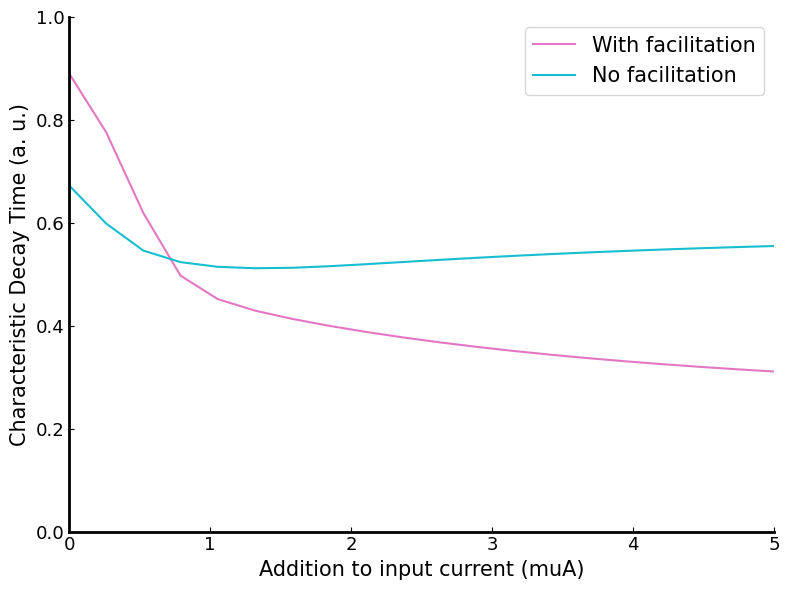

In [6]:
with open('../simulation_results/facilitation/result_char_time.pkl', 'rb') as fp:
    result_dict = pickle.load(fp)
cond_dict = {'0':'No facilitation','1':'With facilitation'}
pararan = np.linspace(0.0,5.0,20)
setMyPlot((8,6))
plt.plot(pararan,np.log(result_dict['1'][0]/result_dict['1'][1]),label = cond_dict['1'],c='tab:pink')
plt.plot(pararan,np.log(result_dict['0'][0]/result_dict['0'][1]),label = cond_dict['0'],c='tab:cyan')
plt.xlabel('Addition to input current (muA)',fontsize=15)
plt.ylabel('Characteristic Decay Time (a. u.)',fontsize=15)
plt.xlim([0,5])
plt.ylim([0.0,1.0])
plt.legend(fontsize=15)
plt.tight_layout()

In [8]:
# # frequency sensitivity in response to facilitation parameters

# # current with/without facilitation
# pararan = [0.03,0.10,0.15,0.18]
# result_dict = {'para':pararan}

# freqarr_all = []

# for i in range(len(pararan)):
#     EF = neural_model.WC_Neuron(Ja = 140.0, Jdp = 110.0, s0=0.011,   
#                    taus = 3.9615, taua = 166.80, taudp = 1.8765, taur = 250.2, 
#                    x0 = 0.9223, u0 = 0.1, uFlag = 1,UU = pararan[i])
#     EX = neural_model.WC_Neuron(Ja = 140.0, Jdp = 110.0, s0=0.011,   
#                    taus = 3.9615, taua = 166.80, taudp = 1.8765, taur = 250.2, 
#                    x0 = 0.9223, u0 = 0.1, uFlag = 1,UU = pararan[i])

#     ListWCNeuron = [EF, IF, EX, IX, MF, MX]

#     freqarr = []
#     inputpara = np.linspace(0.0,1.0,20)

#     for inputs in inputpara:
#         print(inputs)
#         dt = 0.2
#         FinalNN = neural_model.WC_NN(ListWCNeuron,ConnMat, beta = 0.011, dt = dt)
#         T = 10000
#         FinalNN.init_dynamics(T)
#         inp_arr = [0.6+inputs, I0I_F, 0.6+inputs, I0I_X, 0.0, 0.0]
#         for i in range(FinalNN.Npts):
#             FinalNN.update(inp_arr)
#             FinalNN.record(i)
#         tt = np.linspace(0, T, FinalNN.Npts)
#         freqF, ccrateF,_  = metrics.peak_cal_contract(FinalNN.marr[4],FinalNN.marr[4],FinalNN.marr[5],0.0,
#                                               int(FinalNN.Npts/3*2),scale= 0.1,dt=dt)
#         freqarr.append(freqF)
# #         print(freqF)
#     freqarr = np.array([item if item is not None else 0.0 for item in freqarr])
#     freqarr_all.append(freqarr)
# result_dict['result']= np.array(freqarr_all)
# result_dict['input'] = inputpara

# with open('../simulation_results/facilitation/result_change_UU.pkl', 'wb') as fp:
#     pickle.dump(result_dict, fp)


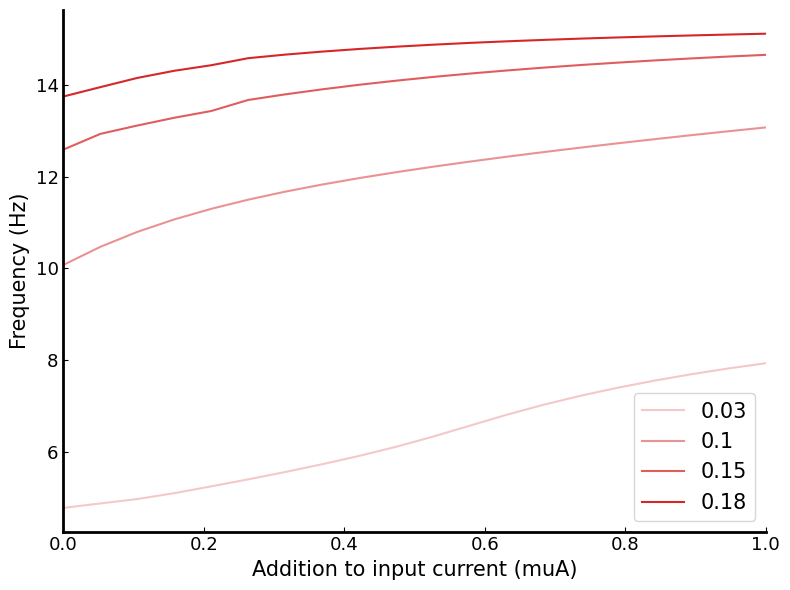

In [9]:
with open('../simulation_results/facilitation/result_change_UU.pkl', 'rb') as fp:
    result_dict = pickle.load(fp)
    
setMyPlot((8,6))
for i in range(len(result_dict['para'])):
    plt.plot(result_dict['input'],result_dict['result'][i],label = result_dict['para'][i],
            color = 'tab:red', alpha = (i+1)/4)

plt.xlabel('Addition to input current (muA)',fontsize=15)
plt.ylabel('Frequency (Hz)',fontsize=15)
plt.xlim([0,1.0])
# plt.ylim([0.0,1.0])
plt.legend(fontsize=15)
plt.tight_layout()


In [9]:
# # frequency sensitivity in response to facilitation parameters

# # current with/without facilitation
# pararan = [50,100,250,400]

# result_dict = {'para':pararan}

# freqarr_all = []

# for label in range(len(pararan)):
    
#     EF = neural_model.WC_Neuron(Ja = 140.0, Jdp = 110.0, s0=0.011,   
#                    taus = 3.9615, taua = 166.80, taudp = 1.8765, taur = pararan[label], 
#                    x0 = 0.9223, u0 = 0.1, uFlag = 1,UU = 0.03)
#     EX = neural_model.WC_Neuron(Ja = 140.0, Jdp = 110.0, s0=0.011,   
#                    taus = 3.9615, taua = 166.80, taudp = 1.8765, taur = pararan[label], 
#                    x0 = 0.9223, u0 = 0.1, uFlag = 1,UU = 0.03)

#     ListWCNeuron = [EF, IF, EX, IX, MF, MX]

#     freqarr = []
#     inputpara = np.linspace(0.0,1.0,40)

#     for inputs in inputpara:
#         print(inputs)
#         dt = 0.2
#         FinalNN = neural_model.WC_NN(ListWCNeuron,ConnMat, beta = 0.011, dt = dt)
#         T = 10000
#         FinalNN.init_dynamics(T)
#         inp_arr = [0.6+inputs, I0I_F, 0.6+inputs, I0I_X, 0.0, 0.0]
#         for i in range(FinalNN.Npts):
#             FinalNN.update(inp_arr)
#             FinalNN.record(i)
#         tt = np.linspace(0, T, FinalNN.Npts)
#         freqF, ccrateF,_  = metrics.peak_cal_contract(FinalNN.marr[4],FinalNN.marr[4],FinalNN.marr[5],0.0,
#                                               int(FinalNN.Npts/3*2),scale= 0.1,dt=dt)
#         freqarr.append(freqF)
# #         print(freqF)
#     freqarr = np.array([item if item is not None else 0.0 for item in freqarr])
#     freqarr_all.append(freqarr)
# result_dict['result']= np.array(freqarr_all)
# result_dict['input'] = inputpara
# with open('../simulation_results/facilitation/result_change_taur.pkl', 'wb') as fp:
#     pickle.dump(result_dict, fp)


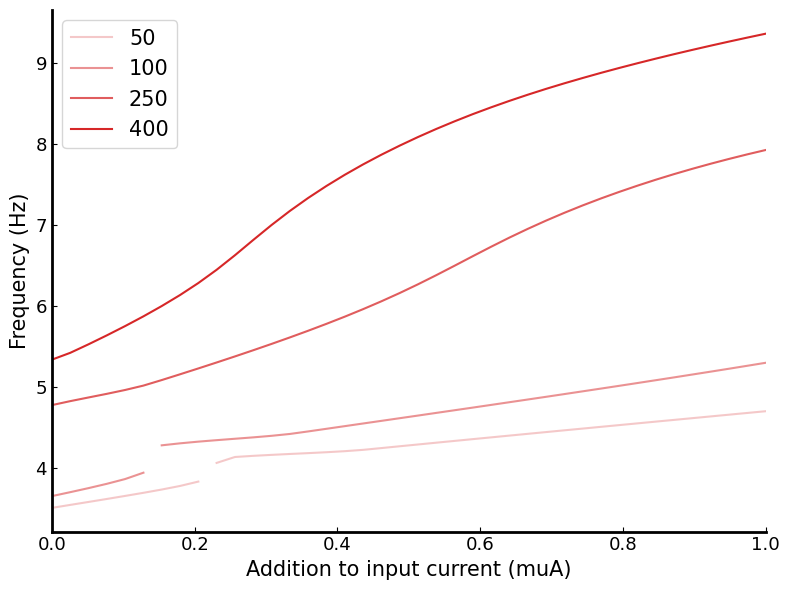

In [10]:
with open('../simulation_results/facilitation/result_change_taur.pkl', 'rb') as fp:
    result_dict = pickle.load(fp)

cut = [9, 6]
setMyPlot((8,6))
for i in range(len(result_dict['para'])):
    
    
    # if 50 and 100: do not connect
    if i<2:
        plt.plot(result_dict['input'][:cut[i]],result_dict['result'][i][:cut[i]],label = result_dict['para'][i],
            color = 'tab:red', alpha = (i+1)/4)
        plt.plot(result_dict['input'][cut[i]:],result_dict['result'][i][cut[i]:],
            color = 'tab:red', alpha = (i+1)/4)
    else:
        plt.plot(result_dict['input'],result_dict['result'][i],label = result_dict['para'][i],
            color = 'tab:red', alpha = (i+1)/4)

plt.xlabel('Addition to input current (muA)',fontsize=15)
plt.ylabel('Frequency (Hz)',fontsize=15)
plt.xlim([0,1.0])
# plt.ylim([0.0,1.0])
plt.legend(fontsize=15)
plt.tight_layout()
